# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

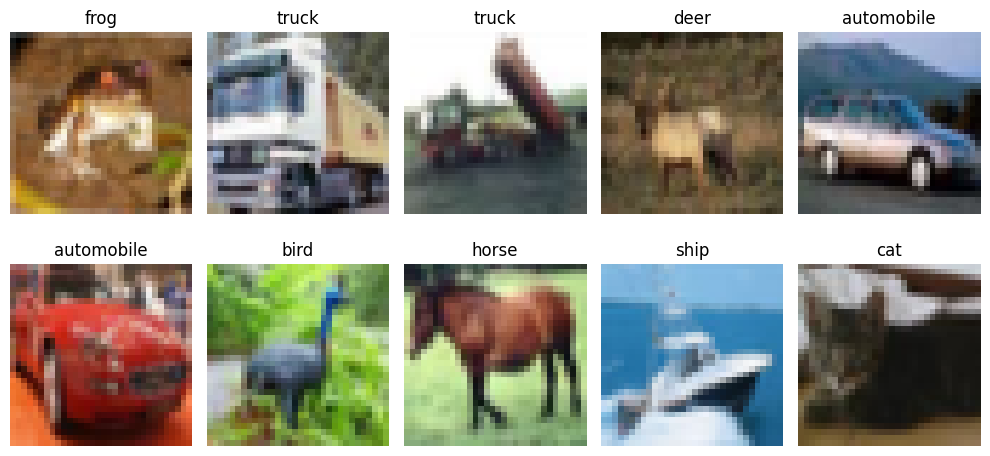

In [19]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [20]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [21]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2696 - loss: 1.9914 - val_accuracy: 0.3464 - val_loss: 1.8151
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3207 - loss: 1.8617 - val_accuracy: 0.3450 - val_loss: 1.8144
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3400 - loss: 1.8153 - val_accuracy: 0.3908 - val_loss: 1.7430
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3568 - loss: 1.7760 - val_accuracy: 0.3954 - val_loss: 1.7184
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3664 - loss: 1.7495 - val_accuracy: 0.3968 - val_loss: 1.6919
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3722 - loss: 1.7341 - val_accuracy: 0.4118 - val_loss: 1.6959
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3796 - loss: 1.7182 - val_accuracy: 0.4210 - val_loss: 1.6505
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3861 - loss: 1.7010 - val_accuracy: 0.

In [22]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4320 - loss: 1.6265
ANN Test Accuracy: 0.4320000112056732


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [23]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.4819 - loss: 1.4590 - val_accuracy: 0.5512 - val_loss: 1.3180
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6203 - loss: 1.0860 - val_accuracy: 0.5890 - val_loss: 1.2056
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6848 - loss: 0.9159 - val_accuracy: 0.6314 - val_loss: 1.0304
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7216 - loss: 0.8015 - val_accuracy: 0.6816 - val_loss: 0.9534
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7530 - loss: 0.7064 - val_accuracy: 0.7112 - val_loss: 0.8348
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7797 - loss: 0.6299 - val_accuracy: 0.6726 - val_loss: 1.0397
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8014 - loss: 0.5638 - val_accuracy: 0.7118 - val_loss: 0.9131
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8217 - loss: 0.5059 - val_accuracy: 

In [24]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7081 - loss: 0.9820
CNN Test Accuracy: 0.7081000208854675


## 📈 Compare Learning Curves

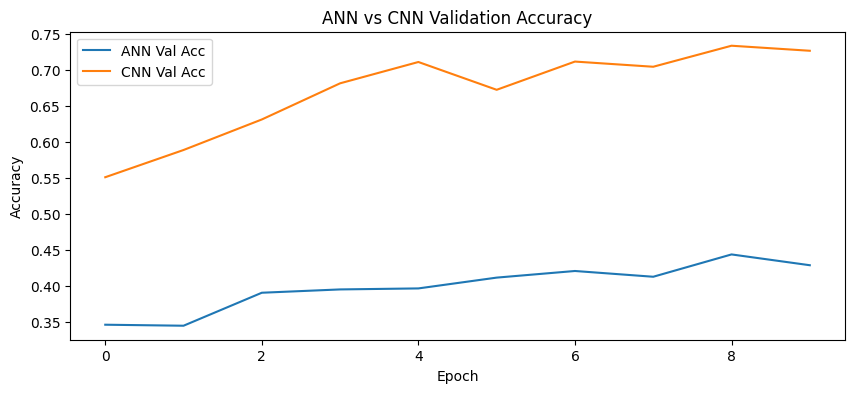

In [25]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3744 - loss: 1.7079 - val_accuracy: 0.4868 - val_loss: 1.4426
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4698 - loss: 1.4715 - val_accuracy: 0.5470 - val_loss: 1.2498
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5054 - loss: 1.3831 - val_accuracy: 0.5266 - val_loss: 1.3665
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.5276 - loss: 1.3291 - val_accuracy: 0.5886 - val_loss: 1.1597
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5452 - loss: 1.2845 - val_accuracy: 0.6040 - val_loss: 1.0980
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5546 - loss: 1.2598 - val_accuracy: 0.5996 - val_loss: 1.1258
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5651 - loss: 1.2257 - val_accuracy: 0.6328 - val_loss: 1.0427
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5753 - loss: 1

In [27]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6365 - loss: 1.0285


# 📊 Final Comparison Table

In [28]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "Aug CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4320
1,CNN,0.7081
2,Aug CNN,0.6365


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

##Task 1 — Increase ANN Layers

Added two more Dense layers (128 and 64 neurons) with their own Dropout.



In [29]:
ann_model_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),   # NEW layer
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),    # NEW layer
    layers.Dense(10, activation='softmax')
])

ann_model_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_model_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2231 - loss: 2.0694 - val_accuracy: 0.3168 - val_loss: 1.8955
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2860 - loss: 1.9293 - val_accuracy: 0.3290 - val_loss: 1.8598
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3048 - loss: 1.8874 - val_accuracy: 0.3494 - val_loss: 1.8412
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3152 - loss: 1.8638 - val_accuracy: 0.3528 - val_loss: 1.8441
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3247 - loss: 1.8478 - val_accuracy: 0.3526 - val_loss: 1.8178
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3305 - loss: 1.8246 - val_accuracy: 0.3782 - val_loss: 1.7447
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3414 - loss: 1.8054 - val_accuracy: 0.3772 - val_loss: 1.7406
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3461 - loss: 1.7934 - val_accuracy: 0

##Task 2 — Change CNN Filters to 64→128->256

In [30]:
cnn_wide = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_wide.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_wide_history = cnn_wide.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.4997 - loss: 1.4207 - val_accuracy: 0.5280 - val_loss: 1.2950
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6389 - loss: 1.0381 - val_accuracy: 0.6024 - val_loss: 1.1487
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7025 - loss: 0.8527 - val_accuracy: 0.5700 - val_loss: 1.2888
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7510 - loss: 0.7241 - val_accuracy: 0.7222 - val_loss: 0.7868
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7840 - loss: 0.6171 - val_accuracy: 0.6942 - val_loss: 0.9174
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8198 - loss: 0.5092 - val_accuracy: 0.7192 - val_loss: 0.8582
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8483 - loss: 0.4310 - val_accuracy: 0.7156 - val_loss: 0.9785
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8702 - loss: 0.3680 - val_accuracy: 

## Task 3,4 — Add EarlyStopping and Running for 20 epochs

In [44]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm, y_train,
    epochs=50,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

print("Training stopped at epoch:", len(cnn_es_history.history['val_accuracy']))

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.4427 - loss: 1.5724 - val_accuracy: 0.5176 - val_loss: 1.4171
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5898 - loss: 1.1799 - val_accuracy: 0.5224 - val_loss: 1.4472
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6509 - loss: 1.0086 - val_accuracy: 0.6074 - val_loss: 1.1836
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6934 - loss: 0.8904 - val_accuracy: 0.6108 - val_loss: 1.1323
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7224 - loss: 0.8055 - val_accuracy: 0.6860 - val_loss: 0.9284
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7499 - loss: 0.7184 - val_accuracy: 0.6890 - val_loss: 0.9658
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7711 - loss: 0.6589 - val_accuracy: 0.7040 - val_loss: 0.9211
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7914 - loss: 0.5991 - val_accuracy: 

##Task 5 — Data Augmentation Training

This is the complete augmented CNN with all best practices applied

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1)
])

aug_cnn_final = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

aug_cnn_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

aug_final_history = aug_cnn_final.fit(
    x_train_norm, y_train,
    epochs=50,
    validation_split=0.1,
    batch_size=64,
    callbacks=[es]
)

aug_final_loss, aug_final_acc = aug_cnn_final.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_final_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.3220 - loss: 1.8722 - val_accuracy: 0.4714 - val_loss: 1.4367
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.4154 - loss: 1.6018 - val_accuracy: 0.4770 - val_loss: 1.5541
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4731 - loss: 1.4684 - val_accuracy: 0.5306 - val_loss: 1.3079
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5068 - loss: 1.3809 - val_accuracy: 0.5644 - val_loss: 1.2291
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5367 - loss: 1.3062 - val_accuracy: 0.5884 - val_loss: 1.2715
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5551 - loss: 1.2598 - val_accuracy: 0.5172 - val_loss: 1.4793
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5779 - loss: 1.2039 - val_accuracy: 0.6288 - val_loss: 1.0949
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5948 - loss: 1.1639 - 

## Final Comparison Table

In [45]:
ann_loss, ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
ann_deep_loss, ann_deep_acc = ann_model_deep.evaluate(x_test_flat, y_test, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
cnn_wide_loss, cnn_wide_acc = cnn_wide.evaluate(x_test_norm, y_test, verbose=0)
cnn_es_loss, cnn_es_acc = cnn_es_model.evaluate(x_test_norm, y_test, verbose=0)
aug_loss, aug_acc = aug_cnn_final.evaluate(x_test_norm, y_test, verbose=0)

results = pd.DataFrame({
    "Model": [
        "ANN (original)",
        "ANN (deeper)",
        "CNN (original)",
        "CNN (wider filters)",
        "CNN (EarlyStopping)",
        "CNN (Aug + EarlyStopping)"
    ],
    "Test Accuracy (%)": [
        round(ann_acc * 100, 2),
        round(ann_deep_acc * 100, 2),
        round(cnn_acc * 100, 2),
        round(cnn_wide_acc * 100, 2),
        round(cnn_es_acc * 100, 2),
        round(aug_acc * 100, 2)
    ]
})

results

,Model,Test Accuracy (%)
0,ANN (original),43.20
1,ANN (deeper),38.86
2,CNN (original),70.81
3,CNN (wider filters),71.76
4,CNN (EarlyStopping),70.29
5,CNN (Aug + EarlyStopping),73.37


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**